In [27]:
import sys
from pathlib import Path

# 🔑 Automatically locate project root by searching upward for the 'sysstrat' folder
project_root = Path.cwd()
while not (project_root / "sysstrat").exists() and project_root != project_root.parent:
    project_root = project_root.parent

# Insert at the front of sys.path so Python finds 'sysstrat' first
sys.path.insert(0, str(project_root))
print(f"✅ Project root resolved: {project_root}")

✅ Project root resolved: c:\Users\igorp\OneDrive\Документы\GitHub\futures_trading_strategies


In [28]:
from sysstrat.data import load_simple_price_csv
from sysstrat.core import Asset, Capital, FixedRiskSizer
from sysstrat.engine import BacktestRunner, RegressionAnalyzer
from sysstrat.strategies import BuyAndHoldStrategy
from sysstrat.visualization import plot_regression

In [29]:
COMISSION = 0.0004
SLIPPAGE = 0.001
data1 = load_simple_price_csv("../data/MCFTR.csv")
data2 = load_simple_price_csv("../data/GLDRUB_TOM.csv")
MCFTR = Asset(ticker= 'MCFTR', price_data=data1, commission_rate=COMISSION, slippage_rate=SLIPPAGE)
GOLD = Asset(ticker= 'GLDRUB', price_data=data2, commission_rate=COMISSION, slippage_rate=SLIPPAGE)

In [30]:
INITIAL_CAPITAL = 100_000
VOLATILITY_WINDOW = 252
RISK_TARGET = 0.2
MAX_LEVERAGE = 1.0

In [31]:
risk_sizer = FixedRiskSizer(
    volatility_window=VOLATILITY_WINDOW, 
    risk_target=RISK_TARGET, 
    expected_sharpe=1, 
    max_leverage=MAX_LEVERAGE
)

# 2. Define Capital
capital = Capital(initial_capital=INITIAL_CAPITAL)

# 3. Initialize Runner and Run
runner1 = BacktestRunner(capital=capital, asset=MCFTR, sizer=risk_sizer)
runner2 = BacktestRunner(capital=capital, asset=GOLD, sizer= risk_sizer)
stock_result = runner1.run(BuyAndHoldStrategy())
gold_result = runner2.run(BuyAndHoldStrategy())

In [32]:
stock_result.print_summary()


════════════════════════════════════════════════════════════
  STRATEGY SUMMARY: Buy and Hold
════════════════════════════════════════════════════════════
  Years:             22.97
  Total Return:      +273.37%
  CAGR:              +11.90%
  Gross Return:      +280.92%
------------------------------------------------------------
  Annual Volatility: 20.31%
  Max Drawdown:      -64.12%
  Avg Drawdown:      -3.70%
------------------------------------------------------------
  Sharpe Ratio:      0.59
  Gross Sharpe:      0.60
  Sortino Ratio:     0.69
------------------------------------------------------------
  Total Fees:        $7,549.96
  Fee Drag Ratio:    0.03
════════════════════════════════════════════════════════════



In [33]:
analyzer = RegressionAnalyzer()

In [34]:
regr = analyzer.analyze(strategy= gold_result.result, benchmark=GOLD.price_data.pct_change())

In [35]:
regr

RegressionResult(strategy_name='Buy and Hold', benchmark_name='GLDRUB', alpha_monthly_pct=0.35263310442293416, alpha_annualized_pct=4.2315972530752095, beta=0.7597994949739257, r_squared=0.9167277401855, alpha_t_stat=2.52742519241826, beta_t_stat=40.36462007069617, n_observations=150, strategy_monthly=0
2013-10-31    0.000000
2013-11-30   -0.012690
2013-12-31   -0.047030
2014-01-31    0.108834
2014-02-28    0.064520
                ...   
2025-11-30   -0.000787
2025-12-31    0.057451
2026-01-31    0.107664
2026-02-28    0.051958
2026-03-31   -0.072623
Freq: ME, Name: 0, Length: 150, dtype: float64, benchmark_monthly=0
2013-10-31    0.010624
2013-11-30   -0.033315
2013-12-31   -0.049259
2014-01-31    0.117243
2014-02-28    0.090529
                ...   
2025-11-30    0.001150
2025-12-31    0.058817
2026-01-31    0.111681
2026-02-28    0.066038
2026-03-31   -0.089203
Freq: ME, Name: GLDRUB, Length: 150, dtype: float64)

<Axes: title={'center': 'Benchmark Regression: Buy and Hold vs GLDRUB\nR²=0.917   α t-stat=2.53'}, xlabel='GLDRUB monthly return (%)', ylabel='Buy and Hold monthly return (%)'>

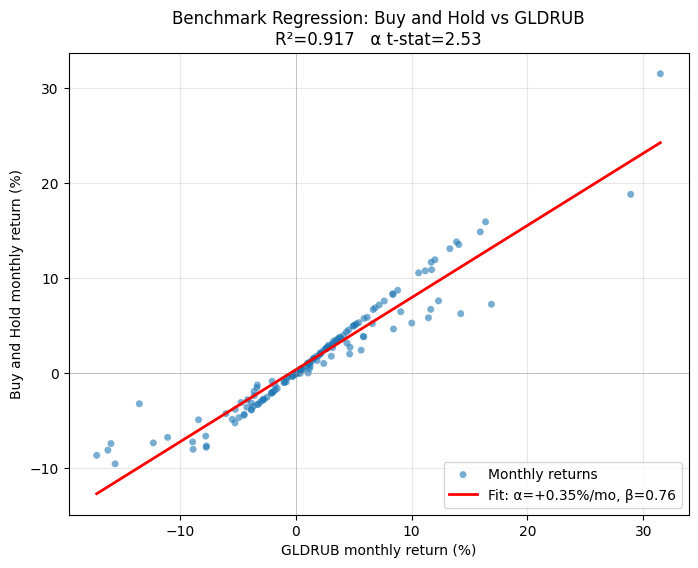

In [36]:
plot_regression(regr)

In [37]:
regr2 = analyzer.analyze(strategy= stock_result.result, benchmark=MCFTR.price_data.pct_change())

<Axes: title={'center': 'Benchmark Regression: Buy and Hold vs MCFTR\nR²=0.880   α t-stat=-0.63'}, xlabel='MCFTR monthly return (%)', ylabel='Buy and Hold monthly return (%)'>

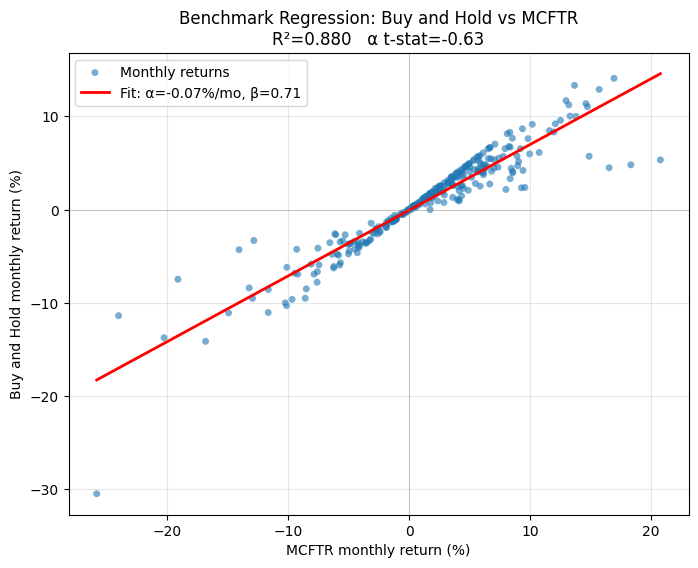

In [38]:
plot_regression(regr2)

<Axes: title={'center': 'Benchmark Regression: Buy and Hold vs Buy and Hold\nR²=0.095   α t-stat=3.46'}, xlabel='Buy and Hold monthly return (%)', ylabel='Buy and Hold monthly return (%)'>

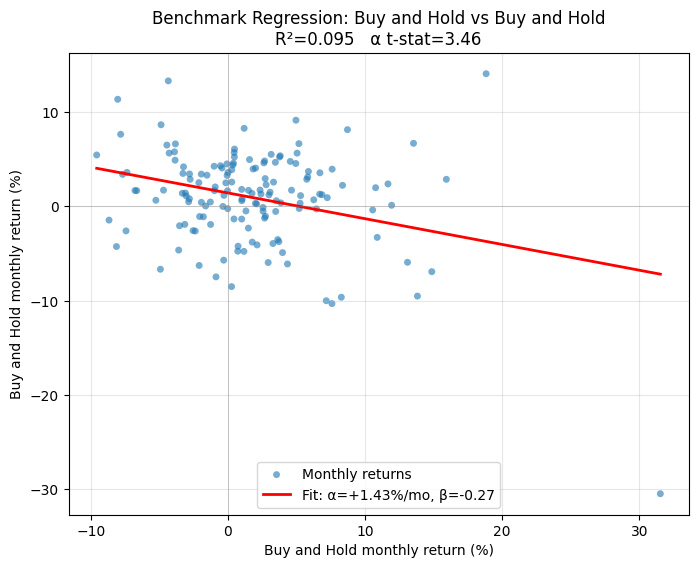

In [39]:
regr_final = analyzer.analyze(strategy= stock_result.result, benchmark=gold_result.result)
plot_regression(regr_final)